In [1]:
import numpy as np
import h5py
import os

def is_file_empty(file_path):
  if not os.path.exists(file_path):
    return False
  return os.path.getsize(file_path) == 0

In [2]:
from matplotlib import pyplot as plt
%matplotlib inline

Text(0.5, 1.0, 'Density Error for Smooth Flow with $P_3$')

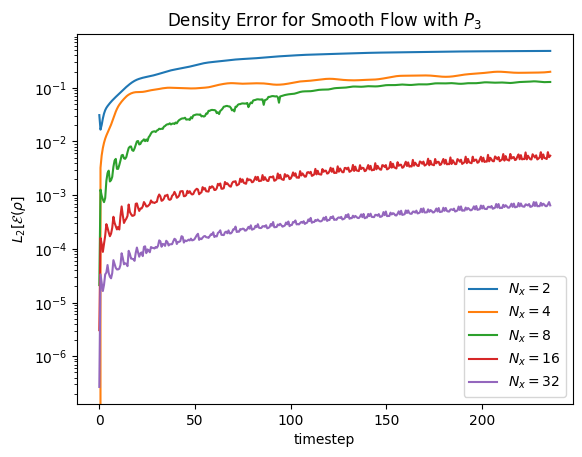

In [3]:
end_vals = np.ndarray((5))


# plt.rcParams['figure.dpi'] = 300
# plt.rcParams['savefig.dpi'] = 300

fig = plt.figure()
ax = fig.add_subplot(111)
for k,name in enumerate(["my1.h5","my2.h5","my3.h5","my4.h5","my5.h5"]):
    f = h5py.File(name)
    errors = np.array(f['Errors.dat'])
    data = np.ndarray((2,len(errors)))
    for i,line in enumerate(errors):
        data[0,i] = line[0]
        data[1,i] = line[3]
    ax.plot(data[0,:],data[1,:],label=r"$N_x=$"+str(2**int(name[2])))
    # saving last point to later calculate convergence
    end_vals[k] = data[1,-1]

ax.set_yscale('log')
ax.set_ylabel(r"$L_2[\mathcal{E}(\rho]$")
ax.set_xlabel("timestep")
ax.legend()
ax.set_title("Density Error for Smooth Flow with $P_3$")

In [4]:
for i in range(len(end_vals)):
    print(round(end_vals[i],4))
print("\n")
for i in range(len(end_vals)-1):
    print(round(np.log2(end_vals[i]/end_vals[i+1]),2))

0.4864
0.1989
0.1284
0.0054
0.0006


1.29
0.63
4.56
3.07
